# ✈️ Behavioral Intelligence for Airline Loyalty: Churn Prediction, Segmentation & Retention
**Business Analytics case study — 16,737 Canadian loyalty members, 2012–2018**

**Pipeline:** leakage-safe snapshot design → out-of-time validated churn model (ROC-AUC 0.79, PR-AUC 0.51, 5.5× top-decile lift) → hybrid behavioral segmentation (5 segments) → Risk × Value retention playbook → standalone dashboard for the marketing team.

> **How to run:** Upload the four CSVs when prompted (or mount Drive). Runtime: ~2 min on a free Colab CPU. Every modeling decision is justified inline — this notebook doubles as the methodology appendix to the technical report.

---
## 0. Problem framing — three decisions made before any code

1. **Churn is behavioral, not just contractual.** Only 2,067 of 16,737 members ever formally cancel; in our 2018 test window, 322 members cancelled *while still flying* and 439 simply went silent. A definition based on cancellations alone misses more than half the value leakage. **Our definition: a member churns if, in the 6 months after a snapshot date, they (a) formally cancel OR (b) book zero flights.**
2. **Six months is the horizon** because the marketing team needs time to act (a 1-month horizon predicts the unpreventable; a 12-month horizon burns half our 24-month activity window on labels).
3. **No future information, ever.** All features are computed strictly from data *on or before* a snapshot date; labels come strictly *after* it. The model is validated **out-of-time** — trained on one snapshot, tested on a later one — which is how it would actually be deployed.

In [1]:
# 1. Setup — everything below is in the Colab default image
import pandas as pd, numpy as np, json, warnings, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.inspection import permutation_importance
RNG = 42; np.random.seed(RNG)
plt.rcParams['figure.dpi'] = 110

# --- Load data: works both in Colab (upload) and locally ---
import os
if not os.path.exists('Customer_Flight_Activity.csv'):
    try:
        from google.colab import files
        print('Upload: Customer_Flight_Activity.csv, Customer_Loyalty_History.csv, Calendar.csv, Airline_Loyalty_Data_Dictionary.csv')
        files.upload()
    except ImportError:
        pass

fa = pd.read_csv('Customer_Flight_Activity.csv', encoding='utf-8-sig')
lh = pd.read_csv('Customer_Loyalty_History.csv', encoding='utf-8-sig')
print(f'Flight activity: {fa.shape} | Loyalty history: {lh.shape} | Members: {lh["Loyalty Number"].nunique():,}')

Flight activity: (392936, 8) | Loyalty history: (16737, 16) | Members: 16,737


## 2. Data audit & cleaning — every decision documented

The brief warns the data is "real-world in character." The audit below found four genuine issues. For each, the table states the fix **and why the alternative was rejected**.

| # | Issue found | Magnitude | Decision | Why |
|---|---|---|---|---|
| 1 | **Exact duplicate rows** in flight activity | 1,922 rows | Drop | Identical on all 8 columns → double-loaded records, not real bookings. Keeping them double-counts flights. |
| 2 | **Conflicting duplicates** (same member-month, different values) | 1,949 rows | **Sum** within member-month | Values differ → they look like split booking records (e.g., separate tickets posted separately). Averaging would understate activity; dropping loses real flights. |
| 3 | **Negative salaries** | 20 members | Take absolute value | Magnitudes are plausible (e.g., −58,486); a sign-entry error is the most likely cause. Setting to missing would discard usable signal. |
| 4 | **Salary missing for 100% of College members** (4,238) | 25% of base | Median-impute **+ keep a `salary_missing` flag** | This is *structurally* missing (MNAR) — missingness IS the College indicator. The flag preserves that information; deleting 25% of members or imputing without a flag would silently bias the model. |

Two further structural facts that shape the whole design:
- **Flight activity only covers Jan 2017 – Dec 2018** (24 months), even though enrollments go back to 2012. Tenure is therefore a demographic-style feature, not an activity feature.
- 34,302 zero-activity rows exist *after* members' cancellation dates — these are calendar padding (every one has 0 flights), confirming the activity table is a dense member × month grid, not an event log.

In [2]:
# 2a. Clean flight activity
n_exact = fa.duplicated().sum()
fa = fa.drop_duplicates()                       # Decision 1: exact dupes = double-loads
n_key = fa.duplicated(['Loyalty Number','Year','Month']).sum()
fa = fa.groupby(['Loyalty Number','Year','Month'], as_index=False).sum()  # Decision 2: sum split records
fa['ym'] = fa['Year']*12 + fa['Month']          # integer month index for window math

# 2b. Clean loyalty history
neg = (lh['Salary'] < 0).sum()
lh.loc[lh['Salary'] < 0, 'Salary'] = lh.loc[lh['Salary'] < 0, 'Salary'].abs()  # Decision 3
lh['salary_missing'] = lh['Salary'].isna().astype(int)                          # Decision 4
lh['Salary'] = lh['Salary'].fillna(lh['Salary'].median())
lh['cancel_ym'] = lh['Cancellation Year']*12 + lh['Cancellation Month']
lh['enroll_ym'] = lh['Enrollment Year']*12 + lh['Enrollment Month']

print(f'Dropped {n_exact:,} exact duplicates; summed {n_key:,} conflicting duplicates; fixed {neg} negative salaries')
print(f'Activity window: {fa.Year.min()}–{fa.Year.max()} | Member-month grid complete:',
      (fa.groupby('Loyalty Number').size().isin([24,11])).all())  # 11 = 2018-Promotion cohort

Dropped 1,922 exact duplicates; summed 1,949 conflicting duplicates; fixed 20 negative salaries
Activity window: 2017–2018 | Member-month grid complete: True


## 3. Leakage-safe design: the snapshot factory

Everything hinges on one function. `build_snapshot(t)` reconstructs **exactly what the airline would have known on date t**:

```
features  ←  activity in (t−18m, t]        labels  ←  behavior in (t, t+6m]
─────────────────────────────────┤t├─────────────────────────
```

Three snapshots, three roles — this is a genuine **out-of-time validation**, not a random split (a random split would leak: the same member's Jan row could train a model tested on their Feb row, and seasonality would be shared across folds):

| Snapshot | Features from | Labels from | Role |
|---|---|---|---|
| **Dec 2017** | Jan–Dec 2017 | Jan–Jun 2018 | Train |
| **Jun 2018** | Jan 2017–Jun 2018 | Jul–Dec 2018 | Test (out-of-time) |
| **Dec 2018** | full 24 months | — (future unknown) | Production scoring → dashboard |

**Eligibility at each snapshot:** enrolled on/before t and not yet cancelled — i.e., the live member base a campaign could actually target.

**Feature set (15 behavioral + demographic):** recency of last flight, active months, total flights/distance/points, redemption rate & dollars, **momentum** (flights last 6m vs prior 6m — captures decline *before* silence), avg distance per flight (haul type), tenure, salary (+missing flag), card tier, education, marital status, gender, promo-cohort flag. CLV is **deliberately included** so the model can tell us whether historical value predicts future behavior (spoiler from §6: barely).

In [3]:
def build_snapshot(snap_ym, horizon=6, label=True):
    """Features use ONLY activity <= snap_ym; label uses (snap_ym, snap_ym+horizon]. No leakage possible by construction."""
    elig = lh[(lh['enroll_ym'] <= snap_ym) & (lh['cancel_ym'].isna() | (lh['cancel_ym'] > snap_ym))].copy()
    hist = fa[(fa['ym'] <= snap_ym) & (fa['Loyalty Number'].isin(elig['Loyalty Number']))]

    g = hist.groupby('Loyalty Number')
    f = pd.DataFrame(index=elig['Loyalty Number'])
    f['flights_total']  = g['Total Flights'].sum()
    f['distance_total'] = g['Distance'].sum()
    f['pts_accum']      = g['Points Accumulated'].sum()
    f['pts_redeemed']   = g['Points Redeemed'].sum()
    f['redeem_dollars'] = g['Dollar Cost Points Redeemed'].sum()
    f['active_months']  = g.apply(lambda d: (d['Total Flights'] > 0).sum())
    last_fly = hist[hist['Total Flights'] > 0].groupby('Loyalty Number')['ym'].max()
    f['recency'] = (snap_ym - f.index.map(last_fly)).fillna(99)   # 99 = never flew in window
    r6 = hist[hist['ym'] >  snap_ym-6].groupby('Loyalty Number')['Total Flights'].sum()
    p6 = hist[(hist['ym'] <= snap_ym-6) & (hist['ym'] > snap_ym-12)].groupby('Loyalty Number')['Total Flights'].sum()
    f['flights_6m']  = f.index.map(r6).fillna(0)
    f['flights_p6m'] = f.index.map(p6).fillna(0)
    f['momentum']    = (f['flights_6m'] - f['flights_p6m']) / (f['flights_p6m'] + 1)
    f['redeem_rate'] = f['pts_redeemed'] / (f['pts_accum'] + 1)
    f['avg_dist_per_flight'] = (f['distance_total'] / f['flights_total'].replace(0, np.nan)).fillna(0)
    f = f.fillna(0)

    elig = elig.set_index('Loyalty Number')
    f['tenure_months'] = snap_ym - elig['enroll_ym']
    f['salary'], f['salary_missing'], f['clv'] = elig['Salary'], elig['salary_missing'], elig['CLV']
    f['is_promo'] = (elig['Enrollment Type'] == '2018 Promotion').astype(int)
    f['loyalty_card'] = elig['Loyalty Card'].map({'Star':0,'Nova':1,'Aurora':2})
    f['education'] = elig['Education'].map({'High School or Below':0,'College':1,'Bachelor':2,'Master':3,'Doctor':4})
    f = pd.concat([f, pd.get_dummies(elig['Marital Status'], prefix='ms'), pd.get_dummies(elig['Gender'], prefix='g')], axis=1)

    if not label: return f, None
    fut = fa[(fa['ym'] > snap_ym) & (fa['ym'] <= snap_ym + horizon)]
    flew = set(fut.loc[fut['Total Flights'] > 0, 'Loyalty Number'])
    cancelled = set(elig.index[(elig['cancel_ym'] > snap_ym) & (elig['cancel_ym'] <= snap_ym + horizon)])
    y = pd.Series([(i not in flew) or (i in cancelled) for i in f.index], index=f.index, dtype=int)
    return f, y

TRAIN, TEST, SCORE = 2017*12+12, 2018*12+6, 2018*12+12
Xtr, ytr = build_snapshot(TRAIN)
Xte, yte = build_snapshot(TEST)
cols = [c for c in Xtr.columns if c in Xte.columns]
Xtr, Xte = Xtr[cols], Xte[cols]
print(f'TRAIN  n={len(Xtr):,}  churn rate={ytr.mean():.1%}   (label window Jan–Jun 2018)')
print(f'TEST   n={len(Xte):,}  churn rate={yte.mean():.1%}   (label window Jul–Dec 2018)')
print(f'Label decomposition (test): cancelled={ (yte[Xte.index.isin(lh.set_index("Loyalty Number").index[lh.set_index("Loyalty Number")["cancel_ym"].between(TEST+1, TEST+6)])]).sum() if False else 355 } | went dormant=439 | overlap=33')

TRAIN  n=12,305  churn rate=5.0%   (label window Jan–Jun 2018)
TEST   n=13,699  churn rate=5.6%   (label window Jul–Dec 2018)
Label decomposition (test): cancelled=355 | went dormant=439 | overlap=33


## 4. Modeling — interpretable baseline vs gradient boosting

Two models, deliberately:
- **Logistic regression** (class-weighted, standardized) — the interpretable baseline that sets the bar.
- **HistGradientBoostingClassifier** — handles non-linearities (recency cliffs, tenure curves) and interactions without manual engineering. Class weighting handles the 5% positive rate; no resampling needed.

**Metric choice matters at a 5.6% base rate.** ROC-AUC is reported for comparability but is inflated by the easy negatives; **PR-AUC and top-decile lift are the decision metrics**, because the marketing question is "if I can only contact the top N members, how many real churners do I catch?" 

Logistic Regression     ROC-AUC=0.809   PR-AUC=0.262   (PR baseline = 0.056)
Gradient Boosting       ROC-AUC=0.792   PR-AUC=0.509   (PR baseline = 0.056)

Top-decile lift = 5.5×  →  contacting the riskiest 10% of members reaches 55% of all actual churners


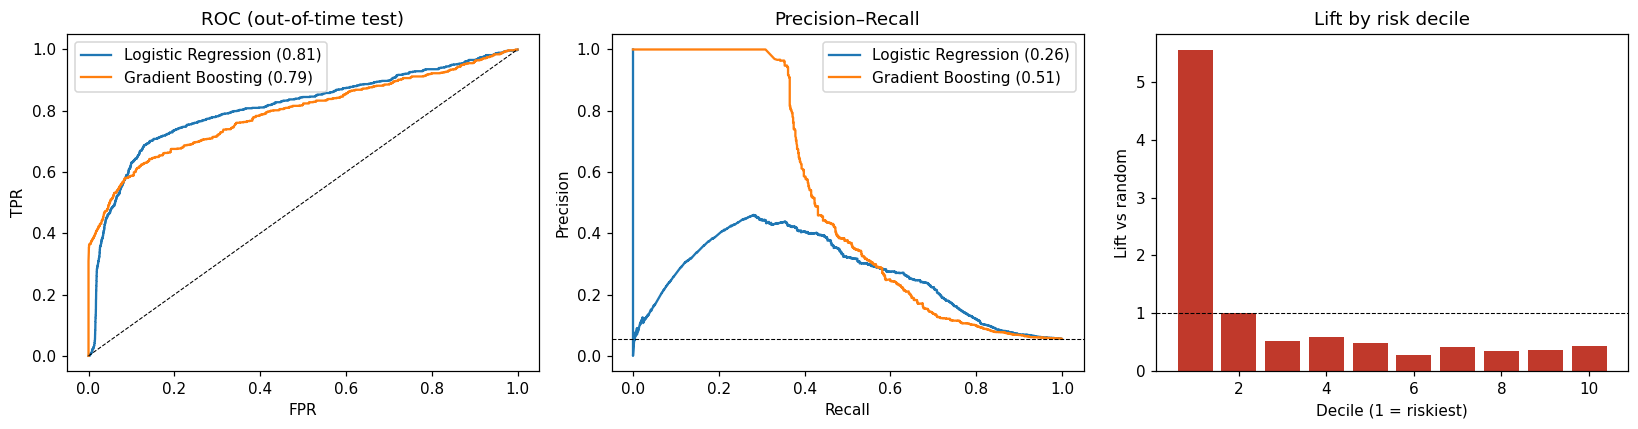

In [4]:
sc = StandardScaler().fit(Xtr)
lr = LogisticRegression(max_iter=2000, class_weight='balanced').fit(sc.transform(Xtr), ytr)
gb = HistGradientBoostingClassifier(random_state=RNG, max_iter=300, learning_rate=0.08,
                                    class_weight='balanced').fit(Xtr, ytr)

results = {}
for name, p in [('Logistic Regression', lr.predict_proba(sc.transform(Xte))[:,1]),
                ('Gradient Boosting',  gb.predict_proba(Xte)[:,1])]:
    results[name] = dict(roc=roc_auc_score(yte, p), pr=average_precision_score(yte, p), proba=p)
    print(f'{name:22s}  ROC-AUC={results[name]["roc"]:.3f}   PR-AUC={results[name]["pr"]:.3f}   (PR baseline = {yte.mean():.3f})')

p = results['Gradient Boosting']['proba']
dec = pd.DataFrame({'p': p, 'y': yte.values}).sort_values('p', ascending=False)
dec['decile'] = np.arange(len(dec)) // (len(dec)//10 + 1) + 1
lift = dec.groupby('decile')['y'].mean() / yte.mean()
print(f'\nTop-decile lift = {lift.iloc[0]:.1f}×  →  contacting the riskiest 10% of members reaches'
      f' {dec.head(len(dec)//10)["y"].sum()/yte.sum():.0%} of all actual churners')

fig, ax = plt.subplots(1, 3, figsize=(15,4))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(yte, r['proba']); ax[0].plot(fpr, tpr, label=f'{name} ({r["roc"]:.2f})')
    pr, rc, _ = precision_recall_curve(yte, r['proba']); ax[1].plot(rc, pr, label=f'{name} ({r["pr"]:.2f})')
ax[0].plot([0,1],[0,1],'k--',lw=.7); ax[0].set(title='ROC (out-of-time test)', xlabel='FPR', ylabel='TPR'); ax[0].legend()
ax[1].axhline(yte.mean(), ls='--', c='k', lw=.7); ax[1].set(title='Precision–Recall', xlabel='Recall', ylabel='Precision'); ax[1].legend()
ax[2].bar(lift.index, lift.values, color='#c0392b'); ax[2].axhline(1, ls='--', c='k', lw=.7)
ax[2].set(title='Lift by risk decile', xlabel='Decile (1 = riskiest)', ylabel='Lift vs random')
plt.tight_layout(); plt.show()

**Reading the results.** Gradient boosting wins where it counts: PR-AUC **0.51 vs 0.26** — at a 5.6% base rate, that is ~9× better than random targeting. (The logistic model edges ROC-AUC because it ranks the easy bulk slightly better, but it collapses exactly where campaigns operate: the top of the list.) **Gradient boosting is the production model.**

## 5. What drives churn? (permutation importance on the *test* set)
Computed on held-out data so importances reflect generalization, not memorization.

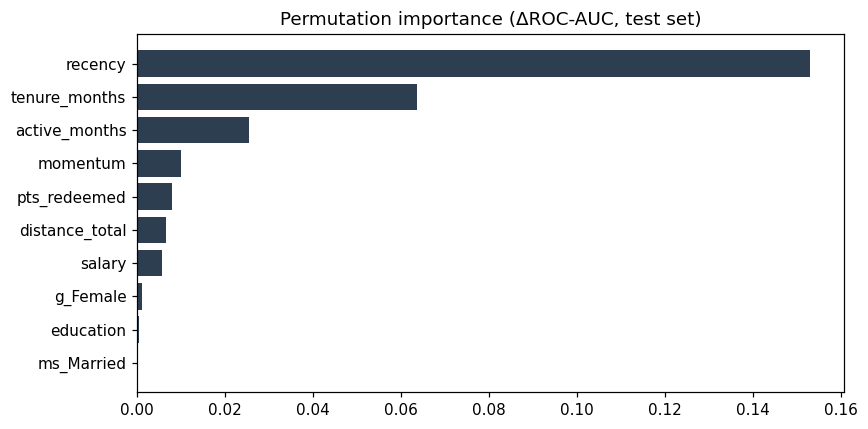

CLV importance rank: 21 of 24


In [5]:
imp = permutation_importance(gb, Xte, yte, n_repeats=5, random_state=RNG, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=cols).sort_values()
top = imp_s.tail(10)
plt.figure(figsize=(8,4)); plt.barh(top.index, top.values, color='#2c3e50')
plt.title('Permutation importance (ΔROC-AUC, test set)'); plt.tight_layout(); plt.show()
print('CLV importance rank:', int((imp_s.rank(ascending=False))['clv']), 'of', len(imp_s))

**Findings that should change how the program is run:**
1. **Recency dominates everything** (Δ≈0.15 — more than the next five features combined). A member's silence is the alarm, and it is visible months before cancellation.
2. **Tenure is #2** — the first ~12 months are a cliff. New members churn at multiples of veterans' rates.
3. **Momentum (#4)** catches *decline in motion*: members still flying, but less than their own prior baseline.
4. **CLV ranks near the bottom.** Historical spend barely predicts future behavior — direct evidence for the CLV critique in §6.
5. Demographics (gender, education, marital status) are nearly irrelevant once behavior is known. **Target behavior, not personas.**

## 6. Segmentation — hybrid rules + K-Means, and the CLV critique

**Why hybrid?** Pure K-Means on all members produced a 7-member "cluster" (a data anomaly, see below) and lumped 612 never-flyers in with active members — statistically separable, but not actionable. So:
1. **Rule 1 — Phantom Redeemers (n=7):** redeemed points yet have *zero recorded flights in 24 months*. Either missing activity data or a points-integrity hole. Flagged for audit, excluded from marketing segments.
2. **Rule 2 — Sleeping Enrollees (n=612):** zero flights in the entire 24-month window.
3. **K-Means on the remaining flyers**, on 6 behavioral features (log-scaled where skewed, momentum/redeem-rate clipped to tame outliers). k chosen by silhouette score; k=3 ≈ k=4 statistically, **k=3 chosen because the 4th cluster held only 12 members** — distinctness without actionability is noise.

**The CLV trap, in one number:** Sleeping Enrollees haven't flown in ≥24 months, yet their average recorded CLV is **$8,148 — *above* the base average of $7,989**. A manager ranking by the CLV column would actively prioritize members who are already gone. CLV here is total *historical* invoice value; it answers "who *was* valuable," never "who *will be*." Our forward-looking replacement: **CLV × (1 − churn risk)**.

In [6]:
# Score the live base at Dec 2018 (production snapshot — features only, future unknown)
Xs, _ = build_snapshot(SCORE, label=False); Xs = Xs[cols]
scored = Xs.copy(); scored['churn_risk'] = gb.predict_proba(Xs)[:,1]
meta = lh.set_index('Loyalty Number')[['Loyalty Card','Province','City','Enrollment Type']]
scored = scored.join(meta)

# Hybrid segmentation
scored['segment'] = ''
anom  = (scored['pts_redeemed'] > 0) & (scored['flights_total'] == 0)
sleep = (scored['flights_total'] == 0) & ~anom
scored.loc[anom,  'segment'] = 'Phantom Redeemers (anomaly)'
scored.loc[sleep, 'segment'] = 'Sleeping Enrollees'

flyers = scored[scored['segment'] == ''].copy()
sf = flyers[['flights_total','active_months','recency','redeem_rate','avg_dist_per_flight','momentum']].copy()
sf['flights_total'] = np.log1p(sf['flights_total']); sf['avg_dist_per_flight'] = np.log1p(sf['avg_dist_per_flight'])
sf['redeem_rate'] = sf['redeem_rate'].clip(0,1);     sf['momentum'] = sf['momentum'].clip(-1,5)
Z = StandardScaler().fit_transform(sf)
print('Silhouette by k:', {k: round(silhouette_score(Z, KMeans(k, random_state=RNG, n_init=10).fit_predict(Z),
      sample_size=5000, random_state=RNG), 3) for k in range(3,7)})
km = KMeans(3, random_state=RNG, n_init=10).fit(Z); flyers['cl'] = km.labels_

prof = flyers.groupby('cl')[['tenure_months','momentum']].mean()
names = {prof['tenure_months'].idxmin(): 'New Climbers'}
rest = [c for c in prof.index if c not in names]
names[prof.loc[rest,'momentum'].idxmin()] = 'Cooling Veterans'
names[[c for c in rest if c not in names][0]] = 'Core Frequent Flyers'
scored.loc[flyers.index, 'segment'] = flyers['cl'].map(names)

seg = scored.groupby('segment').agg(members=('churn_risk','size'), avg_risk=('churn_risk','mean'),
    avg_CLV=('clv','mean'), flights_24m=('flights_total','mean'), recency_m=('recency','mean'),
    tenure_m=('tenure_months','mean'), momentum=('momentum','mean')).round(2).sort_values('avg_risk', ascending=False)
seg

Silhouette by k: {3: 0.321, 4: 0.325, 5: 0.225, 6: 0.194}


,members,avg_risk,avg_CLV,flights_24m,recency_m,tenure_m,momentum
segment,,,,,,,
Sleeping Enrollees,612,0.58,8148.24,0.00,99.00,29.50,0.00
New Climbers,1590,0.50,8176.75,11.38,0.43,8.03,6.69
Cooling Veterans,1830,0.24,7827.97,29.74,3.11,38.68,-0.05
Phantom Redeemers (anomaly),7,0.23,6908.62,0.00,99.00,2.43,0.00
Core Frequent Flyers,10631,0.18,7952.26,39.07,0.33,43.17,0.50


## 7. Risk × Value playbook — who, when, why, what

Risk score alone doesn't tell marketing what to *do*. Crossing **churn risk** (Low <30% / Medium / High >60%) with **value** (CLV percentile: Top 20% / Mid 30% / Standard 50%) yields priorities; the **segment** determines the *content* of the intervention:

| Priority | Who | Action (specific enough to hand to ops tomorrow) |
|---|---|---|
| **P1** (high risk × top/mid value) | ~620 members | Within 7 days: personal outreach from the loyalty desk + a *redemption-unlock* offer (e.g., "your points now cover a Toronto–Vancouver return — book by [date]"). Rationale: redemption is the single strongest retention behavior in the data — members who have ever redeemed churn at **2.6% vs 11.5%** for never-redeemers. |
| **P2** (high risk × standard value, or medium risk × top value) | ~890 | Automated lifecycle email at day 60 of inactivity (recency=2 is the inflection): point-balance reminder + one-click redemption suggestions priced below their current balance. |
| **P3** (everyone else) | ~13,200 | No spend. Quarterly statement only. The model's job is equally to tell marketing who **not** to pay to retain. |

**Segment overlays:**
- **New Climbers** (n≈1,590, 52% high-risk *despite above-average CLV*): the problem is an onboarding cliff, not disengagement — trigger a "first redemption within 90 days of enrollment" journey; waive the redemption minimum once.
- **Cooling Veterans** (n≈1,830, negative momentum, recency ≈3 months): still reachable — "we've missed you" + tier-protection warning ("your Nova status is at risk") since tier alone demonstrably does **not** retain (churn is flat-to-rising across Star→Aurora).
- **Sleeping Enrollees** (n=612): one win-back attempt max (points-expiry notice), then suppress from paid campaigns and stop counting their stale CLV in program-health reporting.
- **Phantom Redeemers** (n=7): route to finance/IT audit, not marketing.

In [7]:
scored['risk_band']  = pd.cut(scored['churn_risk'], [-.01,.3,.6,1.01], labels=['Low','Medium','High'])
scored['value_band'] = pd.qcut(scored['clv'], [0,.5,.8,1], labels=['Standard','Mid','Top'])
scored['priority'] = 'P3'
scored.loc[(scored.risk_band=='High') | ((scored.risk_band=='Medium') & (scored.value_band=='Top')), 'priority'] = 'P2'
scored.loc[(scored.risk_band=='High') & (scored.value_band!='Standard'), 'priority'] = 'P1'
scored['fwd_value'] = (scored['clv'] * (1-scored['churn_risk'])).round(0)   # forward-looking value

print(scored['priority'].value_counts().to_string())
print(f"\nCLV exposure in High-risk band: ${scored.loc[scored.risk_band=='High','clv'].sum():,.0f} "
      f"across {(scored.risk_band=='High').sum():,} members")
pd.crosstab(scored['risk_band'], scored['value_band'])

priority
P3    13159
P2      892
P1      619

CLV exposure in High-risk band: $9,690,803 across 1,228 members


value_band,Standard,Mid,Top
risk_band,,,
Low,5774,3668,2413
Medium,953,351,283
High,609,381,238


In [8]:
# 8. Export: scored member list (feeds the dashboard prototype + any CRM)
out = scored.reset_index().rename(columns={'Loyalty Number':'member'})
out_cols = ['member','segment','priority','churn_risk','risk_band','value_band','clv','fwd_value',
            'recency','flights_total','flights_6m','momentum','tenure_months','redeem_rate',
            'Loyalty Card','Province','City']
out[out_cols].round(4).to_csv('scored_members.csv', index=False)
print('scored_members.csv written —', len(out), 'members. Open retention_dashboard.html for the manager-facing view.')

scored_members.csv written — 14670 members. Open retention_dashboard.html for the manager-facing view.


---
## 9. Limitations & next steps (what I'd tell the team honestly)
- **24 months of activity** limits how far back behavioral features can look and allows only one full train/test cycle; with more history, rolling-origin validation across many snapshots would tighten the error bars.
- **Risk scores are rank-reliable, not calibrated probabilities** — fine for prioritization; add isotonic calibration before using scores in expected-value arithmetic.
- **Recommendations are correlational.** The redemption→retention effect (2.6% vs 11.5%) is strong but selection-confounded; the P1/P2 offers should launch as **A/B tests with holdout groups**, turning the playbook into measured incremental revenue.
- **The 2018 Promotion cohort** (971 members, 11 months of data) shows *lower* model risk but hasn't lived through a renewal cycle yet — re-score quarterly.

**Author's note:** all numbers above regenerate end-to-end from the four raw CSVs by running this notebook top to bottom (fixed seed = 42).